# SafeSearch

In [ ]:
# Optional setup for virtual environments

!pip3 install --upgrade numpy
!pip3 install --upgrade pandas # TODO change to polars
!pip3 install --upgrade sentence-transformers
!pip3 install --upgrade sqlalchemy
!pip3 install --upgrade python-dotenv
!pip3 install --upgrade openai
!pip3 install --upgrade matplotlib
!pip3 install --upgrade psycopg2

In [ ]:
# Standard library modules
import os
import sys
import ast

# Third-party packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import requests
import openai
import psycopg2
import re

# Deep learning and NLP
from sentence_transformers import SentenceTransformer

# Database handling
from sqlalchemy import create_engine, text

# Environment variables
from dotenv import load_dotenv
load_dotenv()

Initialize core components

In [2]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('PG_USER')}"
    + f":{os.getenv('PG_PASSWORD')}"
    + f"@{os.getenv('PG_HOST')}"
    + f":{os.getenv('PG_PORT')}"
    + f"/{os.getenv('PG_DATABASE')}"
)

Define utility functions for embedding and search

In [3]:
def get_embedding(text: str) -> np.ndarray:
    """
    Generates a 384-dimensional embedding for the input text.
    """
    return embedding_model.encode(text)


def vector_to_pg(vec: np.ndarray) -> str:
    """
    Converts a NumPy embedding vector into a PostgreSQL-compatible string.
    Example output: '[0.1,0.2,0.3,...]'
    """
    return '[' + ','.join(map(str, vec.tolist())) + ']'


def search_top_k(query_embedding: np.ndarray, k: int = 3) -> pd.DataFrame:
    """
    Uses the pgvector extension to find the top-k similar rows from the 'search_terms' table.
    
    Parameters:
      query_embedding (np.ndarray): The embedding vector for the physician query.
      k (int): Number of results to retrieve (default=3).
    
    Returns:
      pd.DataFrame with columns ['text', 'similarity'] showing the top-k matches.
    """
    embedding_str = vector_to_pg(query_embedding)
    
    query = text(f"""
        SELECT
            text,
            1 - (vector <-> '{embedding_str}'::vector) AS similarity
        FROM search_terms
        ORDER BY vector <-> '{embedding_str}'::vector
        LIMIT {k}
    """)
    
    with engine.connect() as conn:
        result = conn.execute(query)
        df_results = pd.DataFrame(result.fetchall(), columns=['text', 'similarity'])
    
    return df_results

----

## Database Setup

Read queries from input file

In [ ]:
filename = 'queries.txt'

with open(filename, 'r') as f:
    file_content = f.read()

Preprocess input text data

In [4]:
REMOVE_CTRL_WORDS_BRACES_REGEX = r'{\\[^}]+}'
REMOVE_CURLY_BRACES_REGEX = r'[{}]'

REPLACEMENT = ''

plain_text = re.sub(REMOVE_CTRL_WORDS_BRACES_REGEX, REPLACEMENT, file_content)
plain_text = re.sub(REMOVE_CURLY_BRACES_REGEX, REPLACEMENT, plain_text)

lines = [line.strip() for line in plain_text.splitlines() if line.strip()]

df = pd.DataFrame({'statement': lines})
print(f"Loaded {len(df)} statements.")

Loaded 100 statements.


Generate embeddings

In [ ]:
df['embedding'] = df['statement'].apply(lambda x: get_embedding(x).tolist())

df_to_upload = df.rename(columns={'statement': 'text', 'embedding': 'vector'})

df_to_upload.head()

                                                text  \
0  What are the latest diagnostic criteria and tr...   
1  Differential diagnosis for chest pain in patie...   
2  Optimal management strategies for hypertension...   
3  Evidence-based treatment for heart failure wit...   
4  Diagnostic workup and treatment options for su...   

                                              vector  
0  [0.0200598556548357, 0.009666851721704006, -0....  
1  [0.12008216232061386, 0.02259625867009163, -0....  
2  [-0.0075794970616698265, 0.11912687867879868, ...  
3  [0.05084051191806793, 0.06755831837654114, 0.0...  
4  [-0.023779449984431267, 0.07470016181468964, -...  


Create pgvector extension and 'search_terms' table with 'text' column. Note: the database defined in your .env is assumed to be created.

In [7]:
from sqlalchemy import create_engine, text

try:
    with engine.connect() as conn:
        # Create pgvector extension
        conn.execute(text("CREATE EXTENSION IF NOT EXISTS vector;"))
        conn.commit()

        # Create TABLE search_terms with COLUMN text
        create_table_query = text("""
            CREATE TABLE IF NOT EXISTS search_terms (
                text TEXT NOT NULL,
                vector vector(384)
            );
        """)
        conn.execute(create_table_query)
        conn.commit()

    print("Successfully created extension and table.")
except Exception as e:
    print("Error on database setup actions: ", e)

Successfully created extension and table.


Persist statements and embeddings to database

In [8]:
df_to_upload.to_sql('search_terms', engine, if_exists='append', index=False)

100

----

## Proof-of-Concept

Example physician query containing protected health information (PHI)

In [4]:
query = (
    "My patient, John Doe, 52 years old with diabetes and new onset neuropathy,"
    + " is showing abnormal lab values. What does the latest literature suggest"
    + " about treatment options?"
)

query_embedding = get_embedding(query)
top_matches = search_top_k(query_embedding, k=3)

print("Original Query:\n", query, end="\n")
print("Top 3 Matches from 'search_terms':\n", top_matches)

Original Query:
 My patient, John Doe, 52 years old with diabetes and new onset neuropathy, is showing abnormal lab values. What does the latest literature suggest about treatment options?
Top 3 Matches from 'search_terms':
                                                 text  similarity
0  Best practices for diagnosing and treating dia...    0.175364
1  Current evidence for managing peripheral neuro...    0.100989
2  Latest recommendations for managing type 2 dia...   -0.043089


Create OpenAI client

In [5]:
openai.api_key = os.getenv("OPENAI_API_KEY")
openai.organization = os.getenv("OPENAI_ORG")

client = openai.OpenAI(
    api_key=openai.api_key, 
    organization=openai.organization
)

Define helper for text synthesis and query generation

In [6]:
def synthesize_matches(texts, max_tokens=150, temperature=0.7):
    """
    Synthesizes a list of texts into one cohesive summary.
    
    Parameters:
      texts (list): List of strings to synthesize.
      max_tokens (int): Maximum number of tokens in the generated summary.
      temperature (float): Sampling temperature.
      
    Returns:
      str: The synthesized statement.
    """
    user_prompt = "Please synthesize and summarize the following texts into one" 
    user_prompt += " cohesive statement that captures the overall meaning and key insights:\n\n"
    
    for i, text in enumerate(texts, start=1):
        user_prompt += f"Text {i}: {text}\n\n"
    
    user_prompt += "Provide one overall, well-articulated statement that integrates the above texts."

    system_primer = "You are a Physcian who is a highly detail-oriented query creator."
    system_primer += " You specialize in condensing multiple pieces of text into one coherent,"
    system_primer += " combined question for either Google, Perplexity, or even Pubmed."
    system_primer += " Consider all key points carefully."

    messages = [
        {
            "role": "system",
            "content": system_primer
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]
    
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=messages,
        temperature=temperature,
        max_tokens=max_tokens
    )
    
    return response.choices[0].message.content.strip()

Example query generation

In [7]:
if 'top_matches' not in globals():
    phi_query = (
        "My patient, John Doe, 52 years old with diabetes and new onset neuropathy, "
        "is showing abnormal lab values. What does the latest literature suggest about treatment options?"
    )
    query_embedding = get_embedding(phi_query)
    top_matches = search_top_k(query_embedding, k=3)
    print("Top matches generated:")

print("Top Matches:\n", top_matches)

top_texts = top_matches['text'].tolist()

synthesized_statement = synthesize_matches(top_texts)

print("\nSynthesized Statement:\n", synthesized_statement)

Top Matches:
                                                 text  similarity
0  Best practices for diagnosing and treating dia...    0.175364
1  Current evidence for managing peripheral neuro...    0.100989
2  Latest recommendations for managing type 2 dia...   -0.043089

Synthesized Statement:
 "Summarize the best practices and latest recommendations for diagnosing and managing diabetic neuropathy and peripheral neuropathy in patients with type 2 diabetes mellitus within primary care settings."


In [8]:
# Use the synthesized_statement variable from your previous cell as the search query.
query = synthesized_statement  # Ensure this variable is already defined and non-empty.
print("Original Search Query:", query)

# Remove extra quotation marks if present
if query.startswith('"') and query.endswith('"'):
    query = query[1:-1].strip()
print("Modified Search Query:", query)

# Build url with params
url = "https://www.googleapis.com/customsearch/v1"
params = {
    "key": os.getenv("CUSTOM_SEARCH_API_KEY"),
    "cx": os.getenv("CUSTOM_SEARCH_CX"),
    "q": query,
    "num": 3  # Retrieve top 3 results
}

# Make the GET request to the Google Custom Search API.
response = requests.get(url, params=params)
data = response.json()

# Debug: Print full API response.
print("\nFull API Response:\n", data)

# Check for errors in the API response.
if "error" in data:
    print("Error in API call:", data["error"])
else:
    items = data.get("items", [])
    if not items:
        print("No search results returned. Consider trying a simpler or alternative query.")
    else:
        formatted_results = []
        for item in items:
            title = item.get("title", "No title")
            snippet = item.get("snippet", "No snippet")
            link = item.get("link", "No link")
            formatted_results.append(f"- **{title}** – {snippet} ({link})")
        
        results_statement = "\n".join(formatted_results)
        print("\nGoogle Custom Search Results:")
        print(results_statement)

Original Search Query: "Summarize the best practices and latest recommendations for diagnosing and managing diabetic neuropathy and peripheral neuropathy in patients with type 2 diabetes mellitus within primary care settings."
Modified Search Query: Summarize the best practices and latest recommendations for diagnosing and managing diabetic neuropathy and peripheral neuropathy in patients with type 2 diabetes mellitus within primary care settings.

Full API Response:
 {'kind': 'customsearch#search', 'url': {'type': 'application/json', 'template': 'https://www.googleapis.com/customsearch/v1?q={searchTerms}&num={count?}&start={startIndex?}&lr={language?}&safe={safe?}&cx={cx?}&sort={sort?}&filter={filter?}&gl={gl?}&cr={cr?}&googlehost={googleHost?}&c2coff={disableCnTwTranslation?}&hq={hq?}&hl={hl?}&siteSearch={siteSearch?}&siteSearchFilter={siteSearchFilter?}&exactTerms={exactTerms?}&excludeTerms={excludeTerms?}&linkSite={linkSite?}&orTerms={orTerms?}&dateRestrict={dateRestrict?}&lowRange

In [10]:
# 2. Create a new OpenAI client (v1.x style).
#    This 'OpenAI' class is the entry point for all calls in the new library.
# client = openai.OpenAI(
#     api_key=openai.api_key,
#     organization=openai.organization
# )

# 3. Prepare your context variable (the full Google search results).
#    Ensure 'results_statement' is defined beforehand with all relevant data.
# Example (shortened):
# results_statement = """
# 1) Standards of Care in Diabetes—2023...
# 2) Prevention, assessment, diagnosis...
# 3) Standards of Medical Care in Diabetes—2022...
# ...
# """

system_prompt = (
    "You are a specialized medical consultant with expertise in management of complex queries.You have been provided with a set of Google search results containing current guidelines, evidence-based articles, and recommendations. Provide a thorough, physician-oriented summary and discussion of treatment options, incorporating all relevant details from the provided context, be extremely thourough. Cite your sources in brackets (e.g., [1], [2]) where appropriate, including end of text reference section with full links. Ensure the final answer is comprehensive, referencing every relevant point in the context, and presented in a clear, structured format for clinical decision-making. If any crucial information is missing, state so, but do not invent facts. Remain concise enough for a busy clinician, yet detailed enough to convey key evidence. Your tone should be professional, authoritative, and aligned with current standards of care."
)

context_message = f"Comprehensive Google Results:\n\n{results_statement}\n"

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "system", "content": context_message}
]

# 6. Make the chat completion call with the new interface
response = client.chat.completions.create(
    model="gpt-3.5-turbo",  # or "gpt-4" if you have access
    messages=messages,
    temperature=0.3,
    max_tokens=1200,
    top_p=1.0,
    frequency_penalty=0.0,
    presence_penalty=0.0
)

# 7. Extract and print the final answer
final_answer = response.choices[0].message.content.strip()
print("=== Final Comprehensive Answer ===\n")
print(final_answer)

=== Final Comprehensive Answer ===

Based on the latest guidelines and recommendations, the treatment of diabetic peripheral neuropathy in patients with diabetes like John Doe should involve a multifaceted approach aimed at symptom management, glycemic control, and prevention of complications. Here are the key points to consider:

1. **Symptom Management**:
   - Pain management is crucial in diabetic neuropathy. Options include tricyclic antidepressants, serotonin-norepinephrine reuptake inhibitors (SNRIs), and anticonvulsants like pregabalin and gabapentin [1].
   - Topical agents such as capsaicin cream and lidocaine patches may also provide relief for localized neuropathic pain [1].

2. **Glycemic Control**:
   - Optimal glycemic control is essential to prevent the progression of neuropathy. Tight control of blood glucose levels through lifestyle modifications, oral antidiabetic agents, or insulin therapy is recommended [2].
   - Regular monitoring of HbA1c levels and adjustment of 

### Data Analysis (Optional)

In [11]:
def parse_vector(vector_str: str):
    return ast.literal_eval(vector_str)

Retrieve the top-k matches, and query, from database

In [12]:
top_matches = search_top_k(query_embedding, k=(TOP_K:=3))

with engine.connect() as conn:
    sql_query_vectors = text(f"""
        SELECT
            text,
            vector
        FROM search_terms
        ORDER BY vector <-> '{vector_to_pg(query_embedding)}'::vector
        LIMIT {TOP_K}
    """)
    result = conn.execute(sql_query_vectors)
    rows = result.fetchall()
    
search_texts = []
search_vectors = []
for row in rows:
    search_texts.append(row[0]) # append text
    search_vectors.append(parse_vector(row[1])) # append vector

all_embeddings = [query_embedding] + search_vectors
all_labels = ["QUERY"] + search_texts

Plot embeddings (2D)

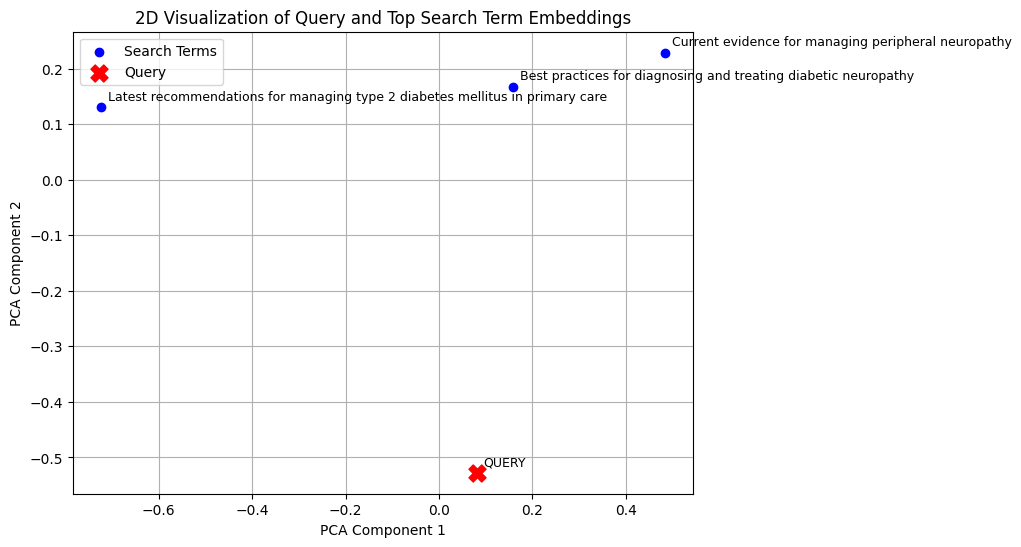

In [13]:
pca = PCA(n_components=2) # Principal Component Analysis (2 components)
embeddings_2d = pca.fit_transform(np.array(all_embeddings))

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[1:, 0], embeddings_2d[1:, 1], color='blue', label='Search Terms')
plt.scatter(embeddings_2d[0, 0], embeddings_2d[0, 1], color='red', label='Query', marker='X', s=150)

for i, label in enumerate(all_labels):
    plt.annotate(label, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=9)

plt.title("2D Visualization of Query and Top Search Term Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

Plot embeddings (3D)

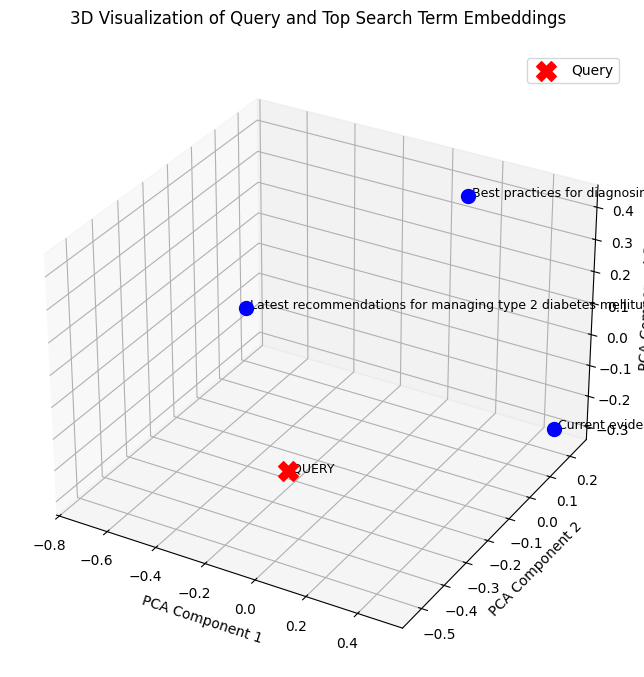

In [14]:
pca_3d = PCA(n_components=3)
embeddings_3d = pca_3d.fit_transform(all_embeddings)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot query in red
ax.scatter(
    embeddings_3d[0, 0],
    embeddings_3d[0, 1],
    embeddings_3d[0, 2],
    color='red',
    marker='X',
    s=200,
    label='Query'
)

# Plot search terms in blue
for i in range(1, len(embeddings_3d)):
    ax.scatter(
        embeddings_3d[i, 0],
        embeddings_3d[i, 1],
        embeddings_3d[i, 2],
        color='blue',
        marker='o',
        s=100
    )

# Annotate points
for i, label in enumerate(all_labels):
    ax.text(
        embeddings_3d[i, 0],
        embeddings_3d[i, 1],
        embeddings_3d[i, 2],
        f" {label}",
        size=9,
        zorder=1
    )

ax.set_title("3D Visualization of Query and Top Search Term Embeddings", pad=20)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.legend()
plt.show()
